In [ ]:
%pip install pymysql
%pip install mysql-connector-python pandas
%pip install SQLAlchemy
%pip install load_dotenv
%pip install pandas
%pip install matplotlib
%pip install ipython-sql
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


# Set up database

In [106]:
from dotenv import load_dotenv
import os

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
dbname = os.getenv("DB_NAME")

from sqlalchemy import create_engine
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{dbname}", connect_args={'init_command': 'SET time_zone="+07:00"'})

# PHONE SCREEN

In [107]:
import pandas as pd
import matplotlib.pyplot as plt

In [108]:
query = "SELECT `DAY`, `SCREEN_TIME`, `SOCIAL`, `SCREEN_TIME` - `SOCIAL` AS `OTHERS` FROM `SAMSUNG_PHONE_SCREEN` NATURAL JOIN `DAY`"
ps = pd.read_sql(query, engine)

In [109]:
ps.head()

,DAY,SCREEN_TIME,SOCIAL,OTHERS
0,2025-06-20,399.0,353.0,46.0
1,2025-06-21,226.0,117.0,109.0
2,2025-06-22,274.0,195.0,79.0
3,2025-06-23,300.0,206.0,94.0
4,2025-06-24,123.0,113.0,10.0


In [110]:
print(ps[['SCREEN_TIME','SOCIAL', 'OTHERS']].describe())

       SCREEN_TIME      SOCIAL      OTHERS
count    18.000000   18.000000   18.000000
mean    293.944444  165.666667  128.277778
std      91.421758   85.955529   66.619910
min     123.000000   47.000000   10.000000
25%     231.750000  106.250000   82.750000
50%     287.000000  144.000000  117.500000
75%     387.000000  216.500000  164.500000
max     426.000000  353.000000  278.000000


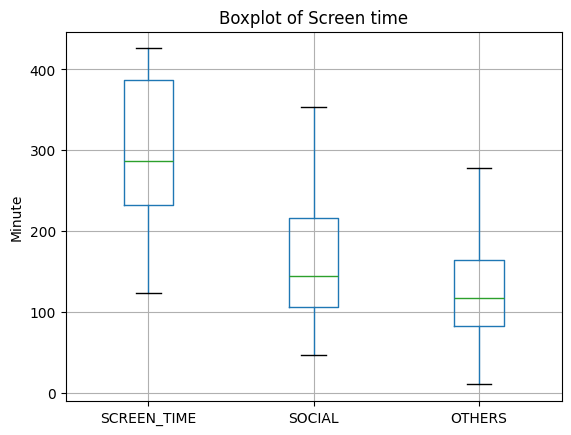

In [111]:
ps.boxplot(column=['SCREEN_TIME','SOCIAL', 'OTHERS'])

plt.title('Boxplot of Screen time')
plt.ylabel('Minute')
plt.show()

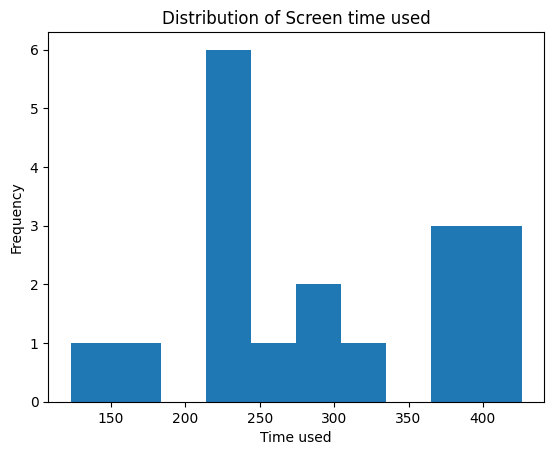

In [112]:
ps['SCREEN_TIME'].plot.hist()
plt.xlabel("Time used")
plt.title("Distribution of Screen time used")
plt.show()

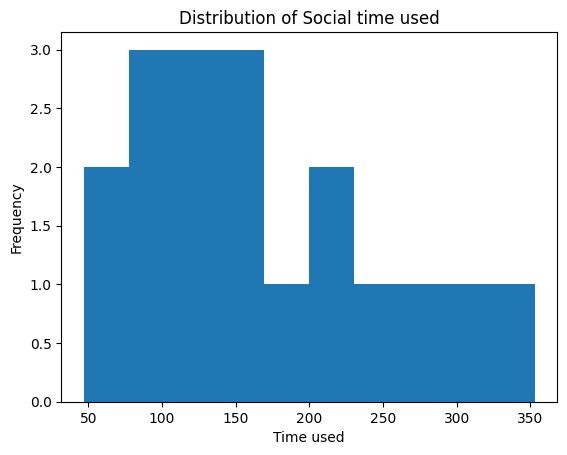

In [113]:
ps['SOCIAL'].plot.hist()
plt.xlabel("Time used")
plt.title("Distribution of Social time used")
plt.show()

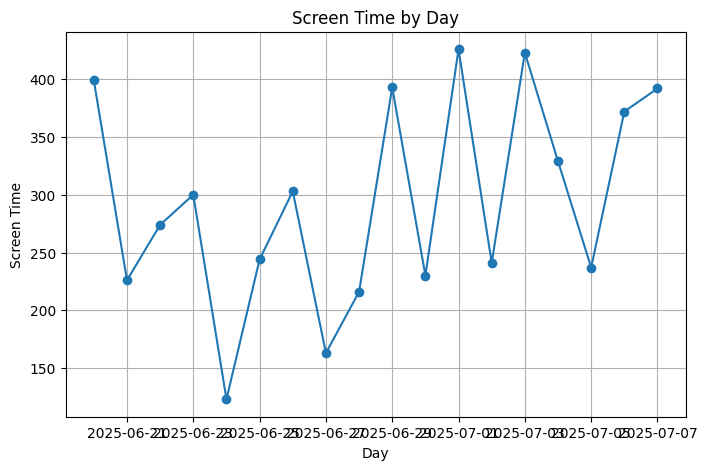

In [114]:
plt.figure(figsize=(8, 5))
plt.plot(ps['DAY'], ps['SCREEN_TIME'], marker='o')
plt.xlabel('Day')
plt.ylabel('Screen Time')
plt.title('Screen Time by Day')
plt.grid(True)
plt.show()

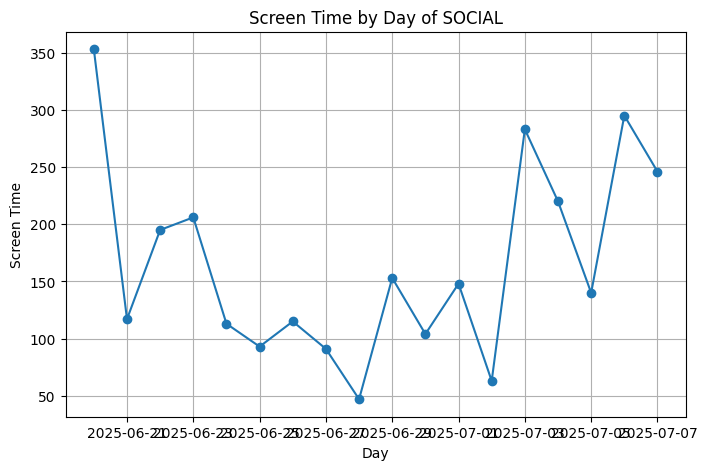

In [115]:
plt.figure(figsize=(8, 5))
plt.plot(ps['DAY'], ps['SOCIAL'], marker='o')
plt.xlabel('Day')
plt.ylabel('Screen Time')
plt.title('Screen Time by Day of SOCIAL')
plt.grid(True)
plt.show()

$z$-score

In [116]:
from scipy.stats import zscore

ps['z_score of SCREEN_TIME'] = zscore(ps['SCREEN_TIME'])
ps['z_score of SOCIAL'] = zscore(ps['SOCIAL'])

ps.head()

,DAY,SCREEN_TIME,SOCIAL,OTHERS,z_score of SCREEN_TIME,z_score of SOCIAL
0,2025-06-20,399.0,353.0,46.0,1.182446,2.242606
1,2025-06-21,226.0,117.0,109.0,-0.764744,-0.582599
2,2025-06-22,274.0,195.0,79.0,-0.224483,0.351155
3,2025-06-23,300.0,206.0,94.0,0.068158,0.482839
4,2025-06-24,123.0,113.0,10.0,-1.924054,-0.630484


Chebyshev's theorem

In [117]:
z = 1.6634959668526281
print(1-(1/(z*z)))

0.6386263390044107
